- In this notebook: continued analysis of top 100 flares by GOES estimated flux, HXR signal analysis and first pass of finding flare durations using count threshold

In [3]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support
from astropy.time import Time
import astropy.units as u

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 
from stixpy.product import Product

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange

import pandas as pd

from scipy.signal import find_peaks

In [4]:
flares = pd.read_csv("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210101_20260130_version1_python.csv")

In [5]:
top100 = flares.sort_values("goes_estimated_mean_flux", ascending=False).head(100)

In [6]:
def get_energy_indices(qtable, ranges):
    energy_indices = []
    for e_min, e_max in ranges:
        start_index = np.where(qtable["e_low"] >= e_min)[0][0]
        end_index = np.where(qtable["e_high"] <= e_max)[0][-1]
        energy_indices.append([int(start_index), int(end_index)])
    return energy_indices
    
def get_stix_df(stix_sci, energy_ranges):
    
    energy_indices = get_energy_indices(stix_sci.energies, energy_ranges)
    counts, errors, times, timedeltas, energies = stix_sci.get_data(detector_indices=[[0, 31]],
                                                                    pixel_indices=[[0, 11]],
                                                                    energy_indices=energy_indices,)
    counts = counts.to(u.ct / u.s / u.keV)
    errors = errors.to(u.ct / u.s / u.keV)
    timedeltas = timedeltas.to(u.s)
    
    times = times
    
    energy_columns = [f"{e['e_low']}-{e['e_high']}" for e in energies]
    
    counts_reshaped = counts[:, 0, 0, :]
    
    counts_df = pd.DataFrame(counts_reshaped, index=times.datetime, columns=energy_columns)
    return counts_df

In [7]:
energy_ranges = [(25.0*u.keV, 50*u.keV), (50.0*u.keV, 100*u.keV)]

In [8]:
def rank_overlaps(start, end, sci_query):
    overlaps=[]
    for n in range(len(sci_query[0])):
        latest_start = max(start, sci_query[0][n][0].datetime)
        earliest_end = min(end, sci_query[0][n][1].datetime)
        
        overlap = earliest_end - latest_start
        overlaps.append((overlap.total_seconds(), n))
        
    return np.array(sorted(overlaps, key=lambda x: x[0], reverse=True))

In [9]:
sci_query = Fido.search(a.Time(top100['start_UTC'].iloc[10], top100['end_UTC'].iloc[10]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
sci_query['stix'].filter_for_latest_version()
sci_query

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str13,str3,int64
2023-01-03T02:10:05.000,2023-01-03T08:15:00.000,STIX,L1,SCI,sci-xray-spec,V04,2301033171


In [10]:
sci_files = Fido.fetch(sci_query[0][0])
sci_data = Product(sci_files)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [11]:
df_test = get_stix_df(sci_data, energy_ranges)
df_test

,25.0 keV-50.0 keV,50.0 keV-100.0 keV
2023-01-03 02:10:05.943,6.720000,2.200000
2023-01-03 02:10:15.193,7.480000,2.206667
2023-01-03 02:10:32.293,7.560494,2.135802
2023-01-03 02:10:40.643,8.800000,2.440000
2023-01-03 02:10:49.093,7.370732,2.246341
...,...,...
2023-01-03 08:14:56.843,7.142857,1.885714
2023-01-03 08:14:57.543,5.942857,2.485714
2023-01-03 08:14:58.243,6.400000,2.371429
2023-01-03 08:14:58.943,7.542857,2.228571


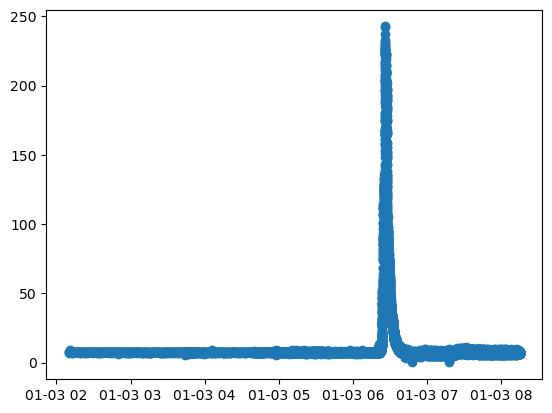

In [12]:
plt.scatter(df_test.index, df_test['25.0 keV-50.0 keV'])

In [13]:
print(df_test.index.freq)

None


In [14]:
df_list=[]
indices=[]
for ind in top100.index:
    sci_query = Fido.search(a.Time(top100['start_UTC'].loc[ind], 
                                   top100['end_UTC'].loc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()

    start = parse_time(top100['start_UTC'].loc[ind]).datetime
    end = parse_time(top100['end_UTC'].loc[ind]).datetime

    overlaps_ranked = rank_overlaps(start, end, sci_query)
    
    for index in overlaps_ranked[:,1]:
        badrange=False
        sci_files = Fido.fetch(sci_query[0][int(index)])
        sci_data = Product(sci_files)
    
        if sci_data.energies["e_high"][len(sci_data.energies["e_high"])-1]<100*u.keV or sci_data.energies["e_low"][0]>25*u.keV:
            badrange=True
        
        if not badrange:
            sci_df = get_stix_df(sci_data, energy_ranges)
            df_list.append(sci_df)
            indices.append(ind)
            break

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [15]:
indices_array = np.array(indices)

In [16]:
i=0
for ind in top100.index:
    #ax=axes[i]
    fig, ax = plt.subplots()
    ax.set_ylabel('ct/(keV s)')
    ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
    sci_df = df_list[np.where(indices_array==ind)[0][0]]
    
    start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
    end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
    
    plot_df = sci_df.truncate(start, end)
        
    plot_df.index = parse_time(plot_df.index).datetime
    
    for n in range(len(plot_df.columns)):
        ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])

    plt.axvline(parse_time(top100['peak_UTC'].loc[ind]).datetime, 0, 1, color = 'darkgrey', linestyle = 'dashed', label='Flare List Peak')
    plt.axvline(plot_df.index[plot_df['25.0 keV-50.0 keV'] == np.max(plot_df['25.0 keV-50.0 keV'])][0], 0, 1, color = 'lightblue', linestyle = 'dashed', label='25-50 keV Peak')
    plt.axvline(parse_time(top100['start_UTC'].loc[ind]).datetime, 0, 1, color = 'yellow', linestyle = 'dashed', label='Flare List Start/End')
    plt.axvline(parse_time(top100['end_UTC'].loc[ind]).datetime, 0, 1, color = 'yellow', linestyle = 'dashed')

    plt.axhline(10, 0, 1, color='red', linestyle='dotted')
    
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize='small')
    fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/top_100_flares_science_data_plot"+str(i)+".png", bbox_inches='tight')

    i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_16876\2924820022.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [17]:
incomplete_file_ind = [5, 18, 26, 29]

In [18]:
for ind in incomplete_file_ind:
    sci_query = Fido.search(a.Time(top100['start_UTC'].iloc[ind], top100['end_UTC'].iloc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()
    sci_query

    sci_files = Fido.fetch(sci_query)
    sci_files = sorted(sci_files)
    
    
    sci_data_A = Product(sci_files[0])
    sci_data_B = Product(sci_files[1])
    
    df_A = get_stix_df(sci_data_A, energy_ranges)
    df_B = get_stix_df(sci_data_B, energy_ranges)
    
    combined_df = pd.concat([df_A, df_B])
    
    combined_df = combined_df.sort_index()
    
    df = combined_df[~combined_df.index.duplicated(keep="first")]

    df_list[ind]=df


Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

In [43]:
exclude = [33, 35, 36, 55, 56, 58, 59, 61, 70, 77, 80, 83, 90, 96]

# df_list_refined = [item for idx, item in enumerate(df_list) if idx not in exclude]
df_list_refined = df_list.copy()
for ind in indices:
    if ind in exclude:
        df_list_refined[ind]='excluded'

indices_refined = list(set(indices)-set(top100.index[exclude]))

In [20]:
stix_query69 = Fido.search(a.Time('2025-06-18T04:39:24.385', '2025-06-18T04:48:36.386'), 
                       a.Instrument.stix, 
                       a.stix.DataProduct.ql_lightcurve)

stix_files69 = Fido.fetch(stix_query69)
stix_lc69 = ts.TimeSeries(stix_files69, concatenate=True)
stix_df69 = stix_lc69.to_dataframe()

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [21]:
def t(x):
    return parse_time(x).datetime

(np.float64(20257.17361111111), np.float64(20257.222222222223))

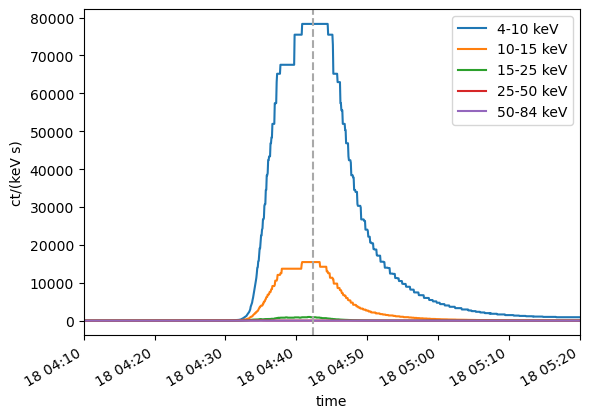

In [22]:
fig, ax = plt.subplots()
ax.set_yscale('linear')
ax.set_ylabel('ct/(keV s)')
stix_df69.plot(ax=ax, y='4-10 keV')
stix_df69.plot(ax=ax, y='10-15 keV')
stix_df69.plot(ax=ax, y='15-25 keV')
stix_df69.plot(ax=ax, y='25-50 keV')
stix_df69.plot(ax=ax, y='50-84 keV')
plt.axvline(parse_time(top100['peak_UTC'].iloc[69]).datetime, 0, 1, color = 'darkgrey', linestyle = 'dashed', label='Peak')
plt.xlim(t('2025-06-18T04:10'), t('2025-06-18T05:20'))

In [23]:
durations = t(flares['end_UTC']) - t(flares['start_UTC'])
list4mean = []
for td in durations:
    td = td.total_seconds()
    list4mean.append(td)
    
np.mean(list4mean)/60

np.float64(20.6231460447526)

In [24]:
i=0
for ind in top100.index:
    #ax=axes[i]
    fig, ax = plt.subplots()
    ax.set_ylabel('ct/(keV s)')
    ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
    sci_df = df_list[np.where(indices_array==ind)[0][0]]
    
    start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
    end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
    
    plot_df = sci_df.truncate(start, end)
        
    plot_df.index = parse_time(plot_df.index).datetime
    
    for n in range(len(plot_df.columns)):
        ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])

    plt.axvline(parse_time(top100['peak_UTC'].loc[ind]).datetime, 0, 1, color = 'darkgrey', linestyle = 'dashed', label='Flare List Peak')
    plt.axvline(plot_df.index[plot_df['25.0 keV-50.0 keV'] == np.max(plot_df['25.0 keV-50.0 keV'])][0], 0, 1, color = 'lightblue', linestyle = 'dashed', label='25-50 keV Peak')
    plt.axvline(parse_time(top100['start_UTC'].loc[ind]).datetime, 0, 1, color = 'yellow', linestyle = 'dashed', label='Flare List Start/End')
    plt.axvline(parse_time(top100['end_UTC'].loc[ind]).datetime, 0, 1, color = 'yellow', linestyle = 'dashed')

    flare = plot_df[plot_df['25.0 keV-50.0 keV']>10]
    tstart = flare.index[0]
    tend = flare.index[-1]

    if t(tend) in plot_df.index:
        plt.axvline(t(tend), 0, 1, color = 'pink', linestyle = 'dotted', label = 'Estimated Start/End')
    if t(tstart) in plot_df.index:
        plt.axvline(t(tstart), 0, 1, color = 'pink', linestyle = 'dotted')
    
    plt.axhline(10, 0, 1, color='red', linestyle='dotted')
    
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize='small')
    fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/top_100_flares_science_data_plot"+str(i)+".png", bbox_inches='tight')

    i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_16876\67922297.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [123]:
data=np.zeros((86, 9))

In [124]:
stats_df = pd.DataFrame(data, columns = ('flare_list_id', 'peak_counts', 'number_of_peaks', 'rise_time', 'decay_time', 'peak_counts (50-100 keV)', 'rise_time (50-100 keV)', 'decay_time (50-100 keV)', 'comments'))

In [125]:
stats_df['flare_list_id'] = stats_df['flare_list_id'].astype(int)
i=0
label=0
for ind in indices:
    if i not in exclude:
        stats_df.loc[label, 'flare_list_id'] = int(ind)
        label+=1
    i+=1

In [131]:
stats_df['rise_time'] = stats_df['rise_time'].astype(str)
stats_df['decay_time'] = stats_df['decay_time'].astype(str)
stats_df['rise_time (50-100 keV)'] = stats_df['rise_time (50-100 keV)'].astype(str)
stats_df['decay_time (50-100 keV)'] = stats_df['decay_time (50-100 keV)'].astype(str)

In [168]:
label=0
i=0
for ind in top100.index:
    if i not in exclude:
        sci_df = df_list[np.where(indices_array==ind)[0][0]]
    
        start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
        end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
    
        plot_df = sci_df.truncate(start, end)
        plot_df.index = parse_time(plot_df.index).datetime 
        
        r = top100['solo_position_AU_distance'].loc[ind]
        
        flare = plot_df[plot_df['25.0 keV-50.0 keV']>10/r**2]
        tstart = flare.index[0]
        tend = flare.index[-1]

        plot_df.truncate(t(tstart), t(tend))
        peak_counts = np.max(plot_df['25.0 keV-50.0 keV'])
        peak_counts_scaled = peak_counts/r**2
        stats_df.loc[label, 'peak_counts'] = peak_counts_scaled

        peak_loc = plot_df.index[plot_df['25.0 keV-50.0 keV'] == peak_counts][0]
        rise_time = peak_loc - tstart
        decay_time = tend - peak_loc
        stats_df.loc[label, 'rise_time'] = str(rise_time).split(" ")[-1]
        stats_df.loc[label, 'decay_time'] = str(decay_time).split(" ")[-1]

        peak_counts_50_100 = np.max(plot_df['50.0 keV-100.0 keV'])
        peak_counts_50_100_scaled = peak_counts_50_100/r**2
        stats_df.loc[label, 'peak_counts (50-100 keV)'] = peak_counts_50_100_scaled
        
        flare_50_100 = plot_df[plot_df['50.0 keV-100.0 keV']>10/r**2]

        if flare_50_100.empty:
            stats_df.loc[label, 'rise_time (50-100 keV)'] = np.nan
            stats_df.loc[label, 'decay_time (50-100 keV)'] = np.nan
        
        if not flare_50_100.empty:
            tstart_50_100 = flare_50_100.index[0]
            tend_50_100 = flare_50_100.index[-1]
            
            peak_loc_50_100 = plot_df.index[plot_df['50.0 keV-100.0 keV'] == peak_counts_50_100][0]
            rise_time_50_100 = peak_loc_50_100 - tstart_50_100
            decay_time_50_100 = tend_50_100 - peak_loc_50_100
            stats_df.loc[label, 'rise_time (50-100 keV)'] = str(rise_time_50_100).split(" ")[-1]
            stats_df.loc[label, 'decay_time (50-100 keV)'] = str(decay_time_50_100).split(" ")[-1]

        peaks, properties = find_peaks(plot_df['25.0 keV-50.0 keV'], distance=30, prominence=0.1*peak_counts)
        stats_df.loc[label, 'number_of_peaks'] = len(peaks)

        label+=1
    i+=1
        

In [142]:
stats_df['comments'] = stats_df['comments'].astype(str)

for i in range(86):
    stats_df.loc[i, 'comments'] = ' '

In [38]:
def print_full(x):
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 2000)
    pd.set_option('display.float_format', '{:20,.2f}'.format)
    pd.set_option('display.max_colwidth', None)
    print(x)
    pd.reset_option('all')

In [169]:
print_full(stats_df)

    flare_list_id          peak_counts      number_of_peaks        rise_time       decay_time  peak_counts (50-100 keV) rise_time (50-100 keV) decay_time (50-100 keV) comments
0           17678             1,017.69                 4.00         00:03:24         00:18:34                    179.37               00:02:21                00:03:08         
1           16121             8,135.72                 1.00         00:01:05  02:09:23.100000                  2,108.86               00:00:44         02:09:23.100000         
2           12921               757.42                 2.00  00:04:46.500000  00:07:31.500000                      9.11                    NaN                     NaN         
3           15873             2,164.68                 2.00         00:03:25         00:07:44                    287.93               00:00:40                00:02:14         
4            8972               129.20                 9.00  00:08:13.500000  01:09:50.300000                     19.50 

C:\Users\derva\AppData\Local\Temp\ipykernel_16876\839608096.py:8: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.reset_option('all')
C:\Users\derva\AppData\Local\Temp\ipykernel_16876\839608096.py:8: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.reset_option('all')


In [33]:
#top100.index.get_loc(top100.loc[8717].name)

In [68]:
top100['solo_position_AU_distance']

17678    0.919223
16121    0.783703
12921    0.740819
15873    0.746657
8972     0.950142
           ...   
19855    0.479995
15986    0.761322
24906    0.843526
2083     0.685926
2130     0.694065
Name: solo_position_AU_distance, Length: 100, dtype: float64

In [73]:
i=0
for ind in indices:
    if ind in indices_refined:
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
        sci_df = df_list[np.where(indices_array==ind)[0][0]]
        
        start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
        end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
        
        plot_df = sci_df.truncate(start, end)
             
        plot_df.index = t(plot_df.index)
        
        for n in range(len(plot_df.columns)):
            ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])
    
        plt.axvline(parse_time(top100['peak_UTC'].loc[ind]).datetime, 0, 1, color = 'darkgrey', linestyle = 'dashed', label='Flare List Peak')
        plt.axvline(plot_df.index[plot_df['25.0 keV-50.0 keV'] == np.max(plot_df['25.0 keV-50.0 keV'])][0], 0, 1, color = 'lightblue', linestyle = 'dashed', label='25-50 keV Peak')
        plt.axvline(parse_time(top100['start_UTC'].loc[ind]).datetime, 0, 1, color = 'yellow', linestyle = 'dashed', label='Flare List Start/End')
        plt.axvline(parse_time(top100['end_UTC'].loc[ind]).datetime, 0, 1, color = 'yellow', linestyle = 'dashed')

        r = top100['solo_position_AU_distance'].loc[ind]
        
        flare = plot_df[plot_df['25.0 keV-50.0 keV']>10/r**2]
        tstart = flare.index[0]
        tend = flare.index[-1]
    
        if t(tend) in plot_df.index:
            plt.axvline(t(tend), 0, 1, color = 'pink', linestyle = 'dotted', label = 'Estimated Start/End')
        if t(tstart) in plot_df.index:
            plt.axvline(t(tstart), 0, 1, color = 'pink', linestyle = 'dotted')
        
        plt.axhline(10/r**2, 0, 1, color='red', linestyle='dotted')
        
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', fontsize='small')
        fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_flares_refined/top_100_flares_science_data_plot"+str(i)+".png", bbox_inches='tight')

        i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_16876\840546852.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [175]:
rise_time_td = pd.to_timedelta(stats_df['rise_time'])
decay_time_td = pd.to_timedelta(stats_df['decay_time'])

durations = rise_time_td+decay_time_td
durations = durations.dt.total_seconds()
durations

0     1318.0
1     7828.1
2      738.0
3      669.0
4     4683.8
       ...  
81     135.0
82     113.0
83      81.0
84     223.0
85     190.5
Length: 86, dtype: float64

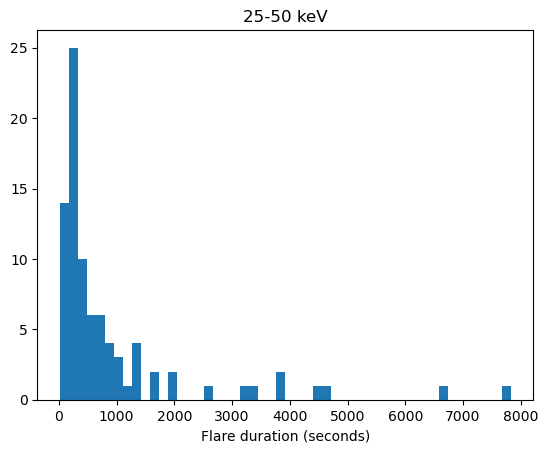

In [176]:
plt.hist(durations, bins=50)
plt.xlabel('Flare duration (seconds)')
plt.title('25-50 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/duration_hist.png", bbox_inches='tight')


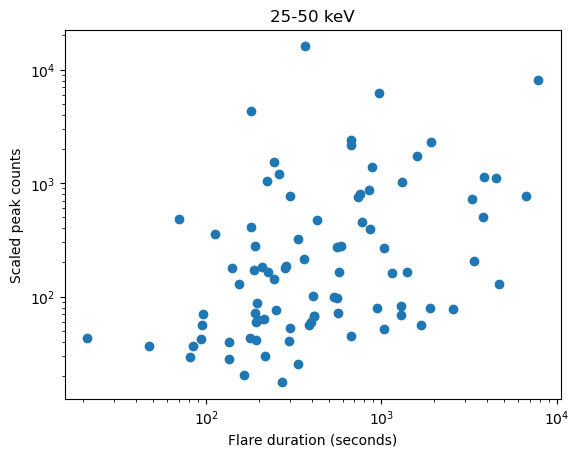

In [177]:
plt.scatter(durations, stats_df['peak_counts'])
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Flare duration (seconds)')
plt.title('25-50 keV')
plt.ylabel('Scaled peak counts')
#plt.xlim(0, 2000)
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/duration_vs_peak_counts.png", bbox_inches='tight')

In [178]:
rise_time_50_100_td = pd.to_timedelta(stats_df['rise_time (50-100 keV)'])
decay_time_50_100_td = pd.to_timedelta(stats_df['decay_time (50-100 keV)'])

durations_50_100 = rise_time_50_100_td+decay_time_50_100_td
durations_50_100 = durations_50_100.dt.total_seconds()
durations_50_100

0      329.0
1     7807.1
2        NaN
3      174.0
4       49.5
       ...  
81       NaN
82       NaN
83       NaN
84      41.5
85       NaN
Length: 86, dtype: float64

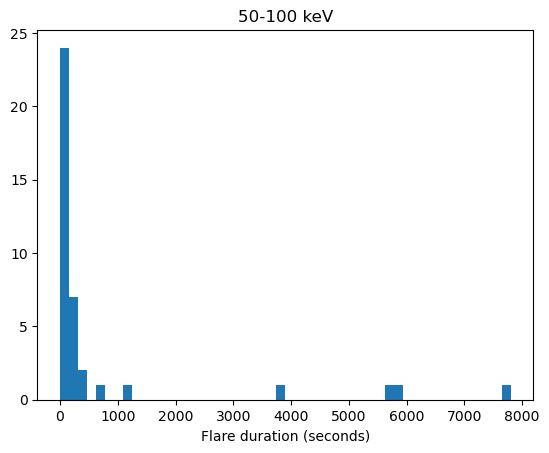

In [179]:
plt.hist(durations_50_100, bins=50)
plt.xlabel('Flare duration (seconds)')
plt.title('50-100 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/duration_hist_50_100_lim10.png", bbox_inches='tight')

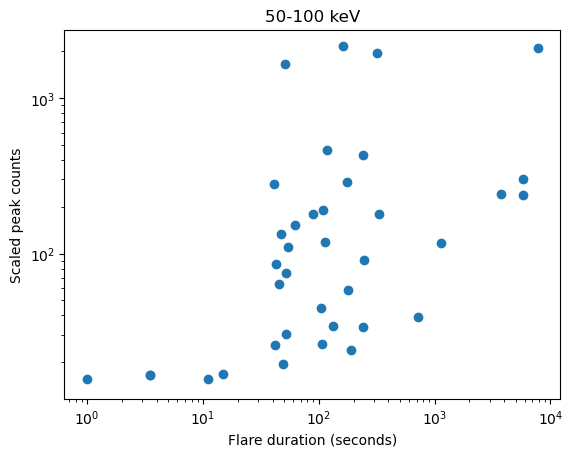

In [180]:
plt.scatter(durations_50_100, stats_df['peak_counts (50-100 keV)'])
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Flare duration (seconds)')
plt.title('50-100 keV')
plt.ylabel('Scaled peak counts')
#plt.xlim(-50, 2000)
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/duration_vs_peak_counts_50_100.png", bbox_inches='tight')

In [181]:
peak_ratios = stats_df['peak_counts (50-100 keV)']/stats_df['peak_counts']

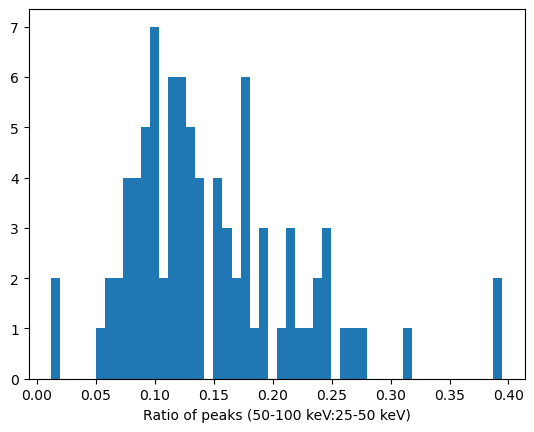

In [182]:
plt.hist(peak_ratios, bins=50)
plt.xlabel('Ratio of peaks (50-100 keV:25-50 keV)')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/peak_ratio_hist_lim10.png", bbox_inches='tight')

In [183]:
from scipy.signal import savgol_filter